In [1]:
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
import sys
sys.path.append("D:\\Program Files\\Lumerical\\v241\\api\\python\\")
import lumapi

In [ ]:
class PWBParameters:
    def __init__(self):
        self.r = 100e-6
        self.l1 = 16e-6
        self.l2 = 100e-6
        self.curve_points = 200
        self.r_11 = 0.6e-6
        self.r_12 = 1.5e-6
        self.r_2 = 1.1e-6
        self.r_3 = 6.2e-6
        self.wavelength = 1.55e-6
        self.mesh_accuracy = 1 
        self.simulation_time = 1500e-15 

In [ ]:
def generate_pwb_path(params):
    """生成PWB路径"""
    r = params.r
    l1 = params.l1
    l2 = params.l2
    l = (170e-6 -(l1 + l2)) / 2
    theta = np.arcsin( 20e-6 / r)
    curve_points = params.curve_points

    # 段1: 水平锥形结构
    x1 = np.linspace(0, l1, curve_points)
    y1 = np.zeros(curve_points)
    z1 = np.zeros(curve_points)
    
    # 段2: 水平结构
    x2 = np.linspace(x1[-1], x1[-1] + l, curve_points)
    y2 = np.zeros(curve_points)
    z2 = np.zeros(curve_points)
    
    # 段3: 向上弯曲
    large_radius = r
    angle1_start = 0
    angle1_end = theta
    t1 = np.linspace(angle1_start, angle1_end, curve_points)
    center3_x = x2[-1]
    center3_z = large_radius
    x3 = center3_x + large_radius * np.sin(t1)
    z3 = center3_z - large_radius * np.cos(t1)
    
    # 段4: 弯曲结构
    end_point3_x = x3[-1]
    end_point3_z = z3[-1]
    tangent_angle2 = angle1_end
    small_radius = r
    center4_x = end_point3_x + small_radius * np.sin(tangent_angle2)
    center4_z = end_point3_z - small_radius * np.cos(tangent_angle2)
    angle3_start = np.pi / 2 - tangent_angle2
    angle3_end = np.pi / 2 + tangent_angle2
    t3 = np.linspace(angle3_start, angle3_end, curve_points)
    x4 = center4_x - small_radius * np.cos(t3)
    z4 = center4_z + small_radius * np.sin(t3)
    
    # 段5: 向下弯曲
    angle4_start = -tangent_angle2
    angle4_end = 0
    t4 = np.linspace(angle4_start, angle4_end, curve_points)
    center5_x = x4[-1] + large_radius * np.sin(abs(angle4_start))
    center5_z = large_radius
    x5 = center5_x + large_radius * np.sin(t4)
    z5 = center5_z - large_radius * np.cos(t4)
    
    # 段6: 水平结构
    x6 = np.linspace(x5[-1], x5[-1] + l, curve_points)
    y6 = np.zeros(curve_points)
    z6 = np.zeros(curve_points)
    
    # 段7: 水平锥形结构
    x7 = np.linspace(x6[-1], x6[-1] + l2, curve_points)
    y7 = np.zeros(curve_points)
    z7 = np.zeros(curve_points)
    
    # 合并所有路径点
    x = np.concatenate((x1, x2, x3, x4, x5, x6, x7))
    y = np.zeros_like(x)
    z = np.concatenate((z1, z2, z3, z4, z5, z6, z7))
    
    path = np.column_stack((x, y, z))
    return path

In [ ]:
def get_radius_at_position_1(t, params):
    """根据路径位置获取半径"""
    curve_points = params.curve_points
    r_11, r_2, r_3 = params.r_11, params.r_2, params.r_3
    
    total_points = 7 * curve_points
    point_idx = int(t * (total_points - 1))
    
    if point_idx < curve_points:
        # 段1: 锥形递减
        local_t = point_idx / curve_points
        return r_11 - (r_11 - r_2) * local_t
    elif point_idx < 6 * curve_points:
        # 段2-6: 恒定半径
        return r_2
    else:
        # 段7: 锥形递增
        local_t = (point_idx - 6 * curve_points) / curve_points
        return r_2 + (r_3 - r_2) * local_t

In [ ]:
def get_radius_at_position_2(t, params):
    """根据路径位置获取半径"""
    curve_points = params.curve_points
    r_12, r_2, r_3 = params.r_12, params.r_2, params.r_3
    
    total_points = 7 * curve_points
    point_idx = int(t * (total_points - 1))
    
    if point_idx < curve_points:
        # 段1: 锥形递减
        local_t = point_idx / curve_points
        return r_12 - (r_12 - r_2) * local_t
    elif point_idx < 6 * curve_points:
        # 段2-6: 恒定半径
        return r_2
    else:
        # 段7: 锥形递增
        local_t = (point_idx - 6 * curve_points) / curve_points
        return r_2 + (r_3 - r_2) * local_t

In [ ]:
def create_pwb_structure_in_fdtd(fdtd, params):
    """在FDTD中创建PWB结构"""
    path = generate_pwb_path(params)
    fdtd.deleteall()
    fdtd.load("D:/simulation/Simulation Project/simulation/LD-PWB-SMF/LD.fsp")
    fdtd.importmaterialdb("D:/simulation/Simulation Project/simulation/database.mdf")
    # 创建Fiber Cladding 和Fiber Core
    fdtd.addcircle()
    fdtd.set("name", "Fiber Cladding")
    fdtd.set("material", "Fiber Cladding")
    fdtd.set("override color opacity from material database", 1)
    fdtd.set("alpha", 0.3)
    fdtd.set("x", 300e-6)
    fdtd.set("y", 0)
    fdtd.set("z", 0)
    fdtd.set("make ellipsoid", 0)
    fdtd.set("radius", 50e-6)
    fdtd.set("z span", 100e-6)
    fdtd.set("first axis", "y")
    fdtd.set("rotation 1", 90)
    fdtd.addcircle()
    fdtd.set("name", "Fiber Core")
    fdtd.set("material", "Fiber Core")
    fdtd.set("x", 300e-6)
    fdtd.set("y", 0)
    fdtd.set("z", 0)
    fdtd.set("make ellipsoid", 0)
    fdtd.set("radius", 4.1e-6)
    fdtd.set("z span", 100e-6)
    fdtd.set("first axis", "y")
    fdtd.set("rotation 1", 90)
    
    # 创建PWB Cladding
    fdtd.addrect()
    fdtd.set("name", "PWB Cladding")
    fdtd.set("material", "PWB Cladding")
    fdtd.set("override color opacity from material database", 1)
    fdtd.set("alpha", 0.3)
    fdtd.set("x", 125e-6)
    fdtd.set("y", 0)
    fdtd.set("z", 0)
    fdtd.set("x span", 250e-6)
    fdtd.set("y span", 50e-6)
    fdtd.set("z span", 50e-6)
    
    # 创建PWB结构
    # 第一段Taper
    num_segments_1 = 100
    path_length = len(path)
    path_length_1 = 200
    segment_length_1 = path_length_1 // num_segments_1
    for i in range(num_segments_1):
        start_idx = i * segment_length_1
        end_idx = min((i + 1) * segment_length_1, path_length_1 - 1)

        if start_idx >= end_idx:
            continue
            
        # 获取段的起始和结束位置
        start_pos = path[start_idx]
        end_pos = path[end_idx]

        # 计算段的中心位置
        center_x = (start_pos[0] + end_pos[0]) / 2
        center_y = (start_pos[1] + end_pos[1]) / 2
        center_z = (start_pos[2] + end_pos[2]) / 2

        # 计算段的长度
        segment_len = np.linalg.norm(end_pos - start_pos)

        # 获取起始和结束半径
        start_t = start_idx / (path_length - 1)
        end_t = end_idx / (path_length - 1)
        start_radius_1 = get_radius_at_position_1(start_t, params)
        end_radius_1 = get_radius_at_position_1(end_t, params)
        avg_radius_1 = (start_radius_1 + end_radius_1) / 2
        start_radius_2 = get_radius_at_position_2(start_t, params)
        end_radius_2 = get_radius_at_position_2(end_t, params)
        avg_radius_2 = (start_radius_2 + end_radius_2) / 2

        # 计算方向向量
        direction = end_pos - start_pos
        norm = np.linalg.norm(direction)
        if norm > 0:
            direction = direction / norm
        else:
            direction = np.array([1, 0, 0])  
        dz, dy, dx = direction[2], direction[1], direction[0]
        theta = np.arctan2(dx, dz) * 180 / np.pi
        phi = np.arcsin(dy) * 180 / np.pi
        fdtd.addcircle()
        fdtd.set("name", f"PWB_segment_{i}")
        fdtd.set("material", "Vancore B")
        fdtd.set("make ellipsoid", 1)
        fdtd.set("x", center_x)
        fdtd.set("y", center_y)
        fdtd.set("z", center_z)
        fdtd.set("radius", avg_radius_1)
        fdtd.set("radius 2", avg_radius_2)
        fdtd.set("z span", segment_len)
        fdtd.set("first axis", "y")
        fdtd.set("rotation 1", theta)
        fdtd.set("second axis", "x")
        fdtd.set("rotation 2", phi)

    # 弯曲结构
    num_segments_2 = 100
    path_length = len(path)
    path_length_2 = 1000
    segment_length_2 = path_length_2 // num_segments_2
    for i in range(num_segments_2):
        start_idx = i * segment_length_2 + 200
        end_idx = min((i + 1) * segment_length_2, path_length_2 - 1) + 200

        if start_idx >= end_idx:
            continue

        # 获取段的起始和结束位置
        start_pos = path[start_idx]
        end_pos = path[end_idx]

        # 计算段的中心位置
        center_x = (start_pos[0] + end_pos[0]) / 2
        center_y = (start_pos[1] + end_pos[1]) / 2
        center_z = (start_pos[2] + end_pos[2]) / 2

        # 计算段的长度
        segment_len = np.linalg.norm(end_pos - start_pos)

        # 获取起始和结束半径
        start_t = start_idx / (path_length - 1)
        end_t = end_idx / (path_length - 1)
        start_radius = get_radius_at_position_1(start_t, params)
        end_radius = get_radius_at_position_1(end_t, params)
        avg_radius = (start_radius + end_radius) / 2
       
        # 计算方向向量
        direction = end_pos - start_pos
        norm = np.linalg.norm(direction)
        if norm > 0:
            direction = direction / norm
        else:
            direction = np.array([1, 0, 0])  
        dz, dy, dx = direction[2], direction[1], direction[0]
        theta = np.arctan2(dx, dz) * 180 / np.pi  # 绕y轴
        phi = np.arcsin(dy) * 180 / np.pi         # 绕x轴
        fdtd.addcircle()
        fdtd.set("name", f"PWB_segment_{i+100}")
        fdtd.set("material", "Vancore B")
        fdtd.set("make ellipsoid", 0)
        fdtd.set("x", center_x)
        fdtd.set("y", center_y)
        fdtd.set("z", center_z)
        fdtd.set("radius", avg_radius)
        fdtd.set("z span", segment_len)
        fdtd.set("first axis", "y")
        fdtd.set("rotation 1", theta)
        fdtd.set("second axis", "x")
        fdtd.set("rotation 2", phi)
    
    # 第二段Taper
    num_segments_3 = 100
    path_length_3 = 200
    path_length = len(path)
    segment_length_3 = path_length_3 // num_segments_3    
    for i in range(num_segments_3):
        start_idx = i * segment_length_3 + 1200
        end_idx = min((i + 1) * segment_length_3, path_length_3 - 1) + 1200

        if start_idx >= end_idx:
            continue

        # 获取段的起始和结束位置
        start_pos = path[start_idx]
        end_pos = path[end_idx]

        # 计算段的中心位置
        center_x = (start_pos[0] + end_pos[0]) / 2
        center_y = (start_pos[1] + end_pos[1]) / 2
        center_z = (start_pos[2] + end_pos[2]) / 2

        # 计算段的长度
        segment_len = np.linalg.norm(end_pos - start_pos)

        # 获取起始和结束半径
        start_t = start_idx / (path_length - 1)
        end_t = end_idx / (path_length - 1)
        start_radius = get_radius_at_position_1(start_t, params)
        end_radius = get_radius_at_position_1(end_t, params)
        avg_radius = (start_radius + end_radius) / 2
        # 计算方向向量
        direction = end_pos - start_pos
        norm = np.linalg.norm(direction)
        if norm > 0:
            direction = direction / norm
        else:
            direction = np.array([1, 0, 0])  
        dz, dy, dx = direction[2], direction[1], direction[0]
        theta = np.arctan2(dx, dz) * 180 / np.pi
        phi = np.arcsin(dy) * 180 / np.pi
        fdtd.addcircle()
        fdtd.set("name", f"pwb_segment_{i+200}")
        fdtd.set("material", "Vancore B")
        fdtd.set("make ellipsoid", 0)
        fdtd.set("x", center_x)
        fdtd.set("y", center_y)
        fdtd.set("z", center_z)
        fdtd.set("radius", avg_radius)
        fdtd.set("z span", segment_len)
        fdtd.set("first axis", "y")
        fdtd.set("rotation 1", theta)
        fdtd.set("second axis", "x")
        fdtd.set("rotation 2", phi)

    return path

In [ ]:
def setup_fdtd_simulation(fdtd, params, path):
    """设置FDTD仿真参数"""
    # 获取结构边界
    x_min, x_max = np.min(path[:, 0]), np.max(path[:, 0])
    y_min, y_max = np.min(path[:, 1]), np.max(path[:, 1])
    z_min, z_max = np.min(path[:, 2]), np.max(path[:, 2])
    
    fdtd.setresource("FDTD","GPU", True)

    # 扩展仿真边界
    margin = 7e-6
    
    # 添加FDTD仿真区域
    fdtd.addfdtd()
    fdtd.set("dimension", "3D")
    # fdtd.set("x min", -margin)
    # fdtd.set("x max", x_max + margin)
    # fdtd.set("x max", 160e-6 + margin)
    # fdtd.set("x min", 15e-6 - margin)
    # fdtd.set("x min", -margin)
    # fdtd.set("x max", params.l1 + margin)
    fdtd.set("x min", 140e-6)
    fdtd.set("x max", 270e-6)
    fdtd.set("y min", y_min - margin)
    fdtd.set("y max", y_max + margin)
    # fdtd.set("z min", z_min - margin)
    # fdtd.set("z max", z_max + margin)
    fdtd.set("z min", -margin)
    fdtd.set("z max", margin)
    fdtd.set("express mode", True)
    
    # 设置边界条件
    fdtd.set("x min bc", "PML")
    fdtd.set("x max bc", "PML")
    fdtd.set("y min bc", "PML")
    fdtd.set("y max bc", "PML")
    fdtd.set("z min bc", "PML")
    fdtd.set("z max bc", "PML")
    
    # 设置网格
    fdtd.set("mesh accuracy", params.mesh_accuracy)
    fdtd.set("mesh type", "auto non-uniform")
    
    # 设置仿真时间
    fdtd.set("simulation time", params.simulation_time)
    
    # 添加光源
    # fdtd.addmode()
    # fdtd.set("name", "source")
    # fdtd.set("injection axis", "x-axis")
    # fdtd.set("direction", "forward")
    # fdtd.set("x", x_min - 3e-6)
    # fdtd.set("y", 0)
    # fdtd.set("z", 0)
    # fdtd.set("y span", 10e-6)
    # fdtd.set("z span", 6e-6)
    # fdtd.set("wavelength start", params.wavelength)
    # fdtd.set("wavelength stop", params.wavelength)

    # 添加导入的光源
    fdtd.addimportedsource()
    fdtd.set("name", "source")
    fdtd.importdataset("D:/simulation/Simulation Project/simulation/LD-PWB-SMF/Section2 output.mat")
    fdtd.set("x", 150e-6)
    fdtd.set("y", 0)
    fdtd.set("z", 0)
    
    # 添加输入端监视器
    fdtd.addpower()
    fdtd.set("name", "input_monitor")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", 160e-6)
    # fdtd.set("x", 15e-6 + margin)
    # fdtd.set("x",  250e-6 - params.l2 + margin)
    fdtd.set("y", 0)
    fdtd.set("z", 0)
    fdtd.set("y span", 2 * margin)
    fdtd.set("z span", 2 * margin)

    # 添加输出端监视器
    fdtd.addpower()
    fdtd.set("name", "output_monitor")
    fdtd.set("monitor type", "2D X-normal")
    # fdtd.set("x", params.l1)
    fdtd.set("x", 260e-6)
    # fdtd.set("x", 255e-6)
    fdtd.set("y", 0)
    fdtd.set("z", 0)
    fdtd.set("y span", 2 * margin)
    fdtd.set("z span", 2 * margin)
    
    fdtd.addpower()
    fdtd.set("name", "output_monitor_2")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", 240e-6)
    fdtd.set("y", 0)
    fdtd.set("z", 0)
    fdtd.set("y span", 2 * margin)
    fdtd.set("z span", 2 * margin)

    # 添加模式分析
    fdtd.addmodeexpansion()
    fdtd.set("name", "mode_expansion")
    fdtd.setexpansion("input", "output_monitor")
    fdtd.set("mode selection", "fundamental TE mode")
    fdtd.set("x", params.l1)
    # fdtd.set("x", 160e-6)
    fdtd.set("x", 260e-6)
    fdtd.set("y", 0)
    fdtd.set("z", 0)
    fdtd.set("y span", 2 * margin)
    fdtd.set("z span", 2 * margin)
    
    # 添加场分布监视器
    fdtd.addpower()
    fdtd.set("name", "transmission_monitor")
    fdtd.set("monitor type", "2D Y-normal")
    fdtd.set("y", 0)
    fdtd.set("x", 205e-6)
    fdtd.set("x span", 130e-6)
    # fdtd.set("x", (15e-6 + 160e-6) / 2)
    # fdtd.set("x span", 160e-6 - 15e-6 + 2 * margin)
    # fdtd.set("x", 250e-6 - params.l2 / 2)
    # fdtd.set("x span", params.l2 + 2 * margin)
    # fdtd.set("z", (z_max + z_min) / 2)
    # fdtd.set("z span", z_max - z_min + 2 * margin)
    fdtd.set("z", 0)
    fdtd.set("z span", 2 * margin)

In [ ]:
def get_data(fdtd, params):
    """运行仿真并分析结果"""

    source_E = fdtd.getresult("source", "mode profile")
    transmission_E = fdtd.getresult("transmission_monitor", "E")
    input_E = fdtd.getresult("input_monitor", "E")
    output_E = fdtd.getresult("output_monitor", "E")
    mode_data = fdtd.getresult("mode_expansion", "expansion for input")
    T_forward = mode_data["T_forward"]
    
    results = {
        'source_E': source_E,
        'transmission_E': transmission_E,
        'input_E': input_E,
        'output_E': output_E,
        'T_forward': T_forward
    }
    
    return results

In [ ]:
def visualize_and_save_results(fdtd, params):
    """可视化结果并保存T_forward数据"""
    
    # 获取数据
    results = get_data(fdtd, params)
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    # 1. 绘制source、input_monitor、output_monitor和transmission_monitor的E场
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

    # source的E场 (2D X-normal)
    source_E = results['source_E']
    E_source = source_E['E']
    Ex_source = E_source[0, :, :, 0, 0]
    Ey_source = E_source[0, :, :, 0, 1]
    Ez_source = E_source[0, :, :, 0, 2]
    E_suorce_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
    y_source = np.squeeze(source_E['y']) * 1e6 #移除长度为1的维度
    z_source = np.squeeze(source_E['z']) * 1e6
    # 测试数组格式和大小
    # print(source_E)
    # print(E_source.shape, y_source.shape, z_source.shape)
    # 创建网格
    Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
    im1 = ax1.pcolormesh(Y_source, Z_source, E_suorce_abs, cmap="jet", shading='auto')
    ax1.set_xlabel('Y (μm)')
    ax1.set_ylabel('Z (μm)')
    ax1.set_title('Source')
    # plt.colorbar(im1, ax=ax1)

    # input_monitor的E场 (2D X-normal)
    input_E = results['input_E']
    E_field_in = input_E['E']
    Ex_in = E_field_in[0, :, :, 0, 0]
    Ey_in = E_field_in[0, :, :, 0, 1]
    Ez_in = E_field_in[0, :, :, 0, 2]
    E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
    y_input = np.squeeze(input_E['y']) * 1e6
    z_input = np.squeeze(input_E['z']) * 1e6
    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
    im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
    ax2.set_xlabel('Y (μm)')
    ax2.set_ylabel('Z (μm)')
    ax2.set_title('Input Monitor')
    # plt.colorbar(im2, ax=ax2)

    # output_monitor的E场 (2D X-normal)
    output_E = results['output_E']
    E_field_out = output_E['E']
    Ex_out = E_field_out[0, :, :, 0, 0]
    Ey_out = E_field_out[0, :, :, 0, 1]
    Ez_out = E_field_out[0, :, :, 0, 2]
    E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
    y_output = np.squeeze(output_E['y']) * 1e6
    z_output = np.squeeze(output_E['z']) * 1e6
    Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
    im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
    ax3.set_xlabel('Y (μm)')
    ax3.set_ylabel('Z (μm)')
    ax3.set_title('Output Monitor')
    # plt.colorbar(im3, ax=ax3)

    # transmission_monitor的E场 (2D Y-normal)
    trans_E = results['transmission_E']
    E_field = trans_E['E']
    Ex = E_field[:, 0, :, 0, 0]
    Ey = E_field[:, 0, :, 0, 1]
    Ez = E_field[:, 0, :, 0, 2]
    E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    x_trans = np.squeeze(trans_E['x']) * 1e6  # (381,)
    z_trans = np.squeeze(trans_E['z']) * 1e6  # (101,)
    X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
    
    im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
    ax4.set_xlabel('X (μm)')
    ax4.set_ylabel('Z (μm)')
    ax4.set_title('Transmission Monitor')
    # plt.colorbar(im4, ax=ax4)

    plt.suptitle("Field")
    plt.tight_layout()
    plt.savefig("../results/Pictures/Section 1.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. 保存T_forward数据
    T_forward = results['T_forward']
    # print(f"T_forward = {T_forward}")
    
    # # 保存到文件
    # with open('../results/T_forward_results.txt', 'a') as f:
    #     f.write(f"T_forward = {T_forward}\n")
    
    return T_forward

In [ ]:
def visualize_and_save_results_3(fdtd, params):
    """可视化结果并保存T_forward数据"""
    
    # 获取数据
    results = get_data(fdtd, params)
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    # 1. 绘制source、input_monitor、output_monitor和transmission_monitor的E场
    fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(18, 6))

    # input_monitor的E场 (2D X-normal)
    input_E = results['input_E']
    E_field_in = input_E['E']
    Ex_in = E_field_in[0, :, :, 0, 0]
    Ey_in = E_field_in[0, :, :, 0, 1]
    Ez_in = E_field_in[0, :, :, 0, 2]
    E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
    y_input = np.squeeze(input_E['y']) * 1e6
    z_input = np.squeeze(input_E['z']) * 1e6
    Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
    im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
    ax2.set_xlabel('Y (μm)')
    ax2.set_ylabel('Z (μm)')
    ax2.set_title('Input Monitor')
    # plt.colorbar(im2, ax=ax2)

    # output_monitor的E场 (2D X-normal)
    output_E = results['output_E']
    E_field_out = output_E['E']
    Ex_out = E_field_out[0, :, :, 0, 0]
    Ey_out = E_field_out[0, :, :, 0, 1]
    Ez_out = E_field_out[0, :, :, 0, 2]
    E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
    y_output = np.squeeze(output_E['y']) * 1e6
    z_output = np.squeeze(output_E['z']) * 1e6
    Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
    im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
    ax3.set_xlabel('Y (μm)')
    ax3.set_ylabel('Z (μm)')
    ax3.set_title('Output Monitor')
    # plt.colorbar(im3, ax=ax3)

    # transmission_monitor的E场 (2D Y-normal)
    trans_E = results['transmission_E']
    E_field = trans_E['E']
    Ex = E_field[:, 0, :, 0, 0]
    Ey = E_field[:, 0, :, 0, 1]
    Ez = E_field[:, 0, :, 0, 2]
    E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    x_trans = np.squeeze(trans_E['x']) * 1e6  # (381,)
    z_trans = np.squeeze(trans_E['z']) * 1e6  # (101,)
    X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
    
    im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
    ax4.set_xlabel('X (μm)')
    ax4.set_ylabel('Z (μm)')
    ax4.set_title('Transmission Monitor')
    # plt.colorbar(im4, ax=ax4)

    plt.suptitle("Field")
    plt.tight_layout()
    plt.savefig("../results/Pictures/Section 3.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    T_forward = results['T_forward']
    return T_forward

In [ ]:
# 单次仿真运行
params = PWBParameters()
fdtd = lumapi.FDTD()
path = create_pwb_structure_in_fdtd(fdtd, params)
setup_fdtd_simulation(fdtd, params, path)
fdtd.save("C:/Users/22122/Desktop/simulation/Lumerical/Learning/LD-PWB-FA/Section 3.fsp")

In [ ]:
# 单次仿真运行
fdtd.run()
get_data(fdtd, params)
T_forward = visualize_and_save_results_3(fdtd, params)

In [ ]:
print(T_forward)

In [ ]:
# r_11和r_12参数化扫描
results_dir = "../simualation/LD-PWB-SMF/results/r_11_r_12_scan"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# 定义参数范围
r_11_values = np.arange(0.2, 2.1, 0.1) * 1e-6
r_12_values = np.arange(0.2, 2.1, 0.1) * 1e-6
all_results = []

# 开始参数扫描
for i, r_11 in enumerate(r_11_values):
    for j, r_12 in enumerate(r_12_values):
        print(f"Processing r_11={r_11*1e6:.1f}μm, r_12={r_12*1e6:.1f}μm ({i*len(r_12_values)+j+1}/{len(r_11_values)*len(r_12_values)})")

        sys.path.append("D:\\Program Files\\Lumerical\\v241\\api\\python\\")
        import lumapi
        fdtd = lumapi.FDTD()
        
        # 更新参数
        params = PWBParameters()
        params.r_11 = r_11
        params.r_12 = r_12
        path = create_pwb_structure_in_fdtd(fdtd, params)
        setup_fdtd_simulation(fdtd, params, path)
        fdtd.save("LD_with_PWB_temp.fsp")
        fdtd.run()
        
        # 获取结果
        results = get_data(fdtd, params)
        T_forward = results['T_forward']
        
        # 保存结果到列表
        all_results.append({
            'r_11': r_11*1e6,
            'r_12': r_12*1e6,
            'T_forward': T_forward[0][0]
        })
        
        # 生成文件名
        filename_base = f"r11_{r_11*1e6:.1f}_r12_{r_12*1e6:.1f}"
        
        # 保存图片
        try:
            # 获取数据用于绘图
            source_E = results['source_E']
            transmission_E = results['transmission_E']
            input_E = results['input_E']
            output_E = results['output_E']

            # 绘图参数
            plt.rcParams['font.family'] = 'Times New Roman'
            plt.rcParams['xtick.labelsize'] = 12
            plt.rcParams['ytick.labelsize'] = 12    
            
            # 绘制场分布图
            fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
            
            # source的E场
            E_source = source_E['E']
            Ex_source = E_source[0, :, :, 0, 0]
            Ey_source = E_source[0, :, :, 0, 1]
            Ez_source = E_source[0, :, :, 0, 2]
            E_source_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
            y_source = np.squeeze(source_E['y']) * 1e6
            z_source = np.squeeze(source_E['z']) * 1e6
            Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
            im1 = ax1.pcolormesh(Y_source, Z_source, E_source_abs, cmap="jet", shading='auto')
            ax1.set_xlabel('Y (μm)')
            ax1.set_ylabel('Z (μm)')
            ax1.set_title('Source')
            
            # input_monitor的E场
            E_field_in = input_E['E']
            Ex_in = E_field_in[0, :, :, 0, 0]
            Ey_in = E_field_in[0, :, :, 0, 1]
            Ez_in = E_field_in[0, :, :, 0, 2]
            E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
            y_input = np.squeeze(input_E['y']) * 1e6
            z_input = np.squeeze(input_E['z']) * 1e6
            Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
            im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
            ax2.set_xlabel('Y (μm)')
            ax2.set_ylabel('Z (μm)')
            ax2.set_title('Input Monitor')
            
            # output_monitor的E场
            E_field_out = output_E['E']
            Ex_out = E_field_out[0, :, :, 0, 0]
            Ey_out = E_field_out[0, :, :, 0, 1]
            Ez_out = E_field_out[0, :, :, 0, 2]
            E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
            y_output = np.squeeze(output_E['y']) * 1e6
            z_output = np.squeeze(output_E['z']) * 1e6
            Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
            im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
            ax3.set_xlabel('Y (μm)')
            ax3.set_ylabel('Z (μm)')
            ax3.set_title('Output Monitor')
            
            # transmission_monitor的E场
            E_field = transmission_E['E']
            Ex = E_field[:, 0, :, 0, 0]
            Ey = E_field[:, 0, :, 0, 1]
            Ez = E_field[:, 0, :, 0, 2]
            E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
            x_trans = np.squeeze(transmission_E['x']) * 1e6
            z_trans = np.squeeze(transmission_E['z']) * 1e6
            X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
            im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
            ax4.set_xlabel('X (μm)')
            ax4.set_ylabel('Z (μm)')
            ax4.set_title('Transmission Monitor')
            
            plt.suptitle(f"r_11={r_11*1e6:.1f}μm, r_12={r_12*1e6:.1f}μm, T_forward={T_forward[0][0]:.4f}")
            plt.tight_layout()
            
            # 保存图片
            fig_path = os.path.join(results_dir, f"{filename_base}_field_plot.png")
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')
            plt.close()
            
            print(f"  T_forward = {T_forward[0][0]:.4f}, 图片已保存: {fig_path}")
            
        except Exception as e:
            print(f"  绘图时出错: {e}")
            print(f"  T_forward = {T_forward[0][0]:.4f}")
        
        fdtd.close()

# 保存所有T_forward结果到文件
results_file = os.path.join(results_dir, "T_forward_sweep_results.txt")
with open(results_file, 'w') as f:
    f.write("r_11(μm)\tr_12(μm)\tT_forward\n")
    for result in all_results:
        f.write(f"{result['r_11']:.1f}\t{result['r_12']:.1f}\t{result['T_forward']:.6f}\n")

In [ ]:
# r_2参数化扫描
results_dir = "../simualation/LD-PWB-SMF/results/r_2_scan"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# 定义参数范围
r_2_values = np.arange(0.1, 2, 0.1) * 1e-6  # 从0.2到0.9微米，步长0.1微米

all_results = []

# 开始参数扫描
for i, r_2 in enumerate(r_2_values):
    print(f"Processing r_2={r_2*1e6:.1f}μm ({i+1}/{len(r_2_values)}")

    sys.path.append("D:\\Program Files\\Lumerical\\v241\\api\\python\\")
    import lumapi
    fdtd = lumapi.FDTD()
    
    # 更新参数
    params = PWBParameters()
    params.r_2 = r_2
    path = create_pwb_structure_in_fdtd(fdtd, params)
    setup_fdtd_simulation(fdtd, params, path)
    fdtd.save("LD_with_PWB_temp.fsp")
    fdtd.run()
    
    # 获取结果
    results = get_data(fdtd, params)
    T_forward = results['T_forward']
    
    # 保存结果到列表
    all_results.append({
        'r_2': r_2*1e6,
        'T_forward': T_forward[0][0]
    })
    
    # 生成文件名
    filename_base = f"r2_{r_2*1e6:.1f}"
    
    # 保存图片
    try:
        # 获取数据用于绘图
        source_E = results['source_E']
        transmission_E = results['transmission_E']
        input_E = results['input_E']
        output_E = results['output_E']

        # 绘图参数
        plt.rcParams['font.family'] = 'Times New Roman'
        plt.rcParams['xtick.labelsize'] = 12
        plt.rcParams['ytick.labelsize'] = 12    
        
        # 绘制场分布图
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
        
        # source的E场
        E_source = source_E['E']
        Ex_source = E_source[0, :, :, 0, 0]
        Ey_source = E_source[0, :, :, 0, 1]
        Ez_source = E_source[0, :, :, 0, 2]
        E_source_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
        y_source = np.squeeze(source_E['y']) * 1e6
        z_source = np.squeeze(source_E['z']) * 1e6
        Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
        im1 = ax1.pcolormesh(Y_source, Z_source, E_source_abs, cmap="jet", shading='auto')
        ax1.set_xlabel('Y (μm)')
        ax1.set_ylabel('Z (μm)')
        ax1.set_title('Source')
        
        # input_monitor的E场
        E_field_in = input_E['E']
        Ex_in = E_field_in[0, :, :, 0, 0]
        Ey_in = E_field_in[0, :, :, 0, 1]
        Ez_in = E_field_in[0, :, :, 0, 2]
        E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
        y_input = np.squeeze(input_E['y']) * 1e6
        z_input = np.squeeze(input_E['z']) * 1e6
        Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
        im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
        ax2.set_xlabel('Y (μm)')
        ax2.set_ylabel('Z (μm)')
        ax2.set_title('Input Monitor')
        
        # output_monitor的E场
        E_field_out = output_E['E']
        Ex_out = E_field_out[0, :, :, 0, 0]
        Ey_out = E_field_out[0, :, :, 0, 1]
        Ez_out = E_field_out[0, :, :, 0, 2]
        E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
        y_output = np.squeeze(output_E['y']) * 1e6
        z_output = np.squeeze(output_E['z']) * 1e6
        Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
        im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
        ax3.set_xlabel('Y (μm)')
        ax3.set_ylabel('Z (μm)')
        ax3.set_title('Output Monitor')
        
        # transmission_monitor的E场
        E_field = transmission_E['E']
        Ex = E_field[:, 0, :, 0, 0]
        Ey = E_field[:, 0, :, 0, 1]
        Ez = E_field[:, 0, :, 0, 2]
        E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
        x_trans = np.squeeze(transmission_E['x']) * 1e6
        z_trans = np.squeeze(transmission_E['z']) * 1e6
        X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
        im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
        ax4.set_xlabel('X (μm)')
        ax4.set_ylabel('Z (μm)')
        ax4.set_title('Transmission Monitor')
        
        plt.suptitle(f"r_2={r_2*1e6:.1f}μm,  T_forward={T_forward[0][0]:.4f}")
        plt.tight_layout()
        
        # 保存图片
        fig_path = os.path.join(results_dir, f"{filename_base}_field_plot.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"  T_forward = {T_forward[0][0]:.4f}, 图片已保存: {fig_path}")
        
    except Exception as e:
        print(f"  绘图时出错: {e}")
        print(f"  T_forward = {T_forward[0][0]:.4f}")
    
    fdtd.close()

# 保存所有T_forward结果到文件
results_file = os.path.join(results_dir, "T_forward_sweep_results.txt")
with open(results_file, 'a') as f:
    f.write("r_2\tT_forward\n")
    for result in all_results:
        f.write(f"{result['r_2']:.1f}\t{result['T_forward']:.6f}\n")

In [ ]:
# l1参数化扫描
results_dir = "../simualation/LD-PWB-SMF/results/l1_scan_2"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# 定义参数范围
l1_values = np.arange(10, 31, 1) * 1e-6

all_results = []

# 开始参数扫描
for i, l1 in enumerate(l1_values):
    print(f"Processing l_1={l1*1e6:.1f}μm ({i+1}/{len(l1_values)}")

    sys.path.append("D:\\Program Files\\Lumerical\\v241\\api\\python\\")
    import lumapi
    fdtd = lumapi.FDTD()
    
    # 更新参数
    params = PWBParameters()
    params.l1 = l1
    path = create_pwb_structure_in_fdtd(fdtd, params)
    setup_fdtd_simulation(fdtd, params, path)
    fdtd.save("LD_with_PWB_temp.fsp")
    fdtd.run()
    
    # 获取结果
    results = get_data(fdtd, params)
    T_forward = results['T_forward']
    
    # 保存结果到列表
    all_results.append({
        'l1': l1*1e6,
        'T_forward': T_forward[0][0]
    })
    
    # 生成文件名
    filename_base = f"l1_{l1*1e6:.1f}"
    
    # 保存图片
    try:
        # 获取数据用于绘图
        source_E = results['source_E']
        transmission_E = results['transmission_E']
        input_E = results['input_E']
        output_E = results['output_E']

        # 绘图参数
        plt.rcParams['font.family'] = 'Times New Roman'
        plt.rcParams['xtick.labelsize'] = 12
        plt.rcParams['ytick.labelsize'] = 12    
        
        # 绘制场分布图
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
        
        # source的E场
        E_source = source_E['E']
        Ex_source = E_source[0, :, :, 0, 0]
        Ey_source = E_source[0, :, :, 0, 1]
        Ez_source = E_source[0, :, :, 0, 2]
        E_source_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
        y_source = np.squeeze(source_E['y']) * 1e6
        z_source = np.squeeze(source_E['z']) * 1e6
        Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
        im1 = ax1.pcolormesh(Y_source, Z_source, E_source_abs, cmap="jet", shading='auto')
        ax1.set_xlabel('Y (μm)')
        ax1.set_ylabel('Z (μm)')
        ax1.set_title('Source')
        
        # input_monitor的E场
        E_field_in = input_E['E']
        Ex_in = E_field_in[0, :, :, 0, 0]
        Ey_in = E_field_in[0, :, :, 0, 1]
        Ez_in = E_field_in[0, :, :, 0, 2]
        E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
        y_input = np.squeeze(input_E['y']) * 1e6
        z_input = np.squeeze(input_E['z']) * 1e6
        Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
        im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
        ax2.set_xlabel('Y (μm)')
        ax2.set_ylabel('Z (μm)')
        ax2.set_title('Input Monitor')
        
        # output_monitor的E场
        E_field_out = output_E['E']
        Ex_out = E_field_out[0, :, :, 0, 0]
        Ey_out = E_field_out[0, :, :, 0, 1]
        Ez_out = E_field_out[0, :, :, 0, 2]
        E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
        y_output = np.squeeze(output_E['y']) * 1e6
        z_output = np.squeeze(output_E['z']) * 1e6
        Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
        im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
        ax3.set_xlabel('Y (μm)')
        ax3.set_ylabel('Z (μm)')
        ax3.set_title('Output Monitor')
        
        # transmission_monitor的E场
        E_field = transmission_E['E']
        Ex = E_field[:, 0, :, 0, 0]
        Ey = E_field[:, 0, :, 0, 1]
        Ez = E_field[:, 0, :, 0, 2]
        E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
        x_trans = np.squeeze(transmission_E['x']) * 1e6
        z_trans = np.squeeze(transmission_E['z']) * 1e6
        X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
        im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
        ax4.set_xlabel('X (μm)')
        ax4.set_ylabel('Z (μm)')
        ax4.set_title('Transmission Monitor')
        
        plt.suptitle(f"l1={l1*1e6:.1f}μm,  T_forward={T_forward[0][0]:.4f}")
        plt.tight_layout()
        
        # 保存图片
        fig_path = os.path.join(results_dir, f"{filename_base}_field_plot.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"  T_forward = {T_forward[0][0]:.4f}, 图片已保存: {fig_path}")
        
    except Exception as e:
        print(f"  绘图时出错: {e}")
        print(f"  T_forward = {T_forward[0][0]:.4f}")
    
    fdtd.close()

# 保存所有T_forward结果到文件
results_file = os.path.join(results_dir, "T_forward_sweep_results.txt")
with open(results_file, 'a') as f:
    f.write("l1\tT_forward\n")
    for result in all_results:
        f.write(f"{result['l1']:.1f}\t{result['T_forward']:.6f}\n")

In [ ]:
# r参数化扫描
results_dir = "../simualation/LD-PWB-SMF/results/r_scan_r2=1.0"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# 定义参数范围
r_values = np.arange(30, 125, 5) * 1e-6

all_results = []

# 开始参数扫描
for i, r in enumerate(r_values):
    print(f"Processing r={r*1e6:.1f}μm ({i+1}/{len(r_values)}")

    sys.path.append("D:\\Program Files\\Lumerical\\v241\\api\\python\\")
    import lumapi
    fdtd = lumapi.FDTD()
    
    # 更新参数
    params = PWBParameters()
    params.r = r
    path = create_pwb_structure_in_fdtd(fdtd, params)
    setup_fdtd_simulation(fdtd, params, path)
    fdtd.save("LD_with_PWB_temp.fsp")
    fdtd.run()
    
    # 获取结果
    results = get_data(fdtd, params)
    T_forward = results['T_forward']
    
    # 保存结果到列表
    all_results.append({
        'r': r*1e6,
        'T_forward': T_forward[0][0]
    })
    
    # 生成文件名
    filename_base = f"r_{r*1e6:.1f}"
    
    # 保存图片
    try:
        # 获取数据用于绘图
        # source_E = results['source_E']
        transmission_E = results['transmission_E']
        input_E = results['input_E']
        output_E = results['output_E']

        # 绘图参数
        plt.rcParams['font.family'] = 'Times New Roman'
        plt.rcParams['xtick.labelsize'] = 12
        plt.rcParams['ytick.labelsize'] = 12    
        
        # 绘制场分布图
        fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(18, 6))
        
        # source的E场
        # E_source = source_E['E']
        # Ex_source = E_source[0, :, :, 0, 0]
        # Ey_source = E_source[0, :, :, 0, 1]
        # Ez_source = E_source[0, :, :, 0, 2]
        # E_source_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
        # y_source = np.squeeze(source_E['y']) * 1e6
        # z_source = np.squeeze(source_E['z']) * 1e6
        # Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
        # im1 = ax1.pcolormesh(Y_source, Z_source, E_source_abs, cmap="jet", shading='auto')
        # ax1.set_xlabel('Y (μm)')
        # ax1.set_ylabel('Z (μm)')
        # ax1.set_title('Source')
        
        # input_monitor的E场
        E_field_in = input_E['E']
        Ex_in = E_field_in[0, :, :, 0, 0]
        Ey_in = E_field_in[0, :, :, 0, 1]
        Ez_in = E_field_in[0, :, :, 0, 2]
        E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
        y_input = np.squeeze(input_E['y']) * 1e6
        z_input = np.squeeze(input_E['z']) * 1e6
        Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
        im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
        ax2.set_xlabel('Y (μm)')
        ax2.set_ylabel('Z (μm)')
        ax2.set_title('Input Monitor')
        
        # output_monitor的E场
        E_field_out = output_E['E']
        Ex_out = E_field_out[0, :, :, 0, 0]
        Ey_out = E_field_out[0, :, :, 0, 1]
        Ez_out = E_field_out[0, :, :, 0, 2]
        E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
        y_output = np.squeeze(output_E['y']) * 1e6
        z_output = np.squeeze(output_E['z']) * 1e6
        Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
        im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
        ax3.set_xlabel('Y (μm)')
        ax3.set_ylabel('Z (μm)')
        ax3.set_title('Output Monitor')
        
        # transmission_monitor的E场
        E_field = transmission_E['E']
        Ex = E_field[:, 0, :, 0, 0]
        Ey = E_field[:, 0, :, 0, 1]
        Ez = E_field[:, 0, :, 0, 2]
        E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
        x_trans = np.squeeze(transmission_E['x']) * 1e6
        z_trans = np.squeeze(transmission_E['z']) * 1e6
        X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
        im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
        ax4.set_xlabel('X (μm)')
        ax4.set_ylabel('Z (μm)')
        ax4.set_title('Transmission Monitor')
        
        plt.suptitle(f"r={r*1e6:.1f}μm,  T_forward={T_forward[0][0]:.4f}")
        plt.tight_layout()
        
        # 保存图片
        fig_path = os.path.join(results_dir, f"{filename_base}_field_plot.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"  T_forward = {T_forward[0][0]:.4f}, 图片已保存: {fig_path}")
        
    except Exception as e:
        print(f"  绘图时出错: {e}")
        print(f"  T_forward = {T_forward[0][0]:.4f}")
    
    fdtd.close()

# 保存所有T_forward结果到文件
results_file = os.path.join(results_dir, "T_forward_sweep_results.txt")
with open(results_file, 'a') as f:
    f.write("r\tT_forward\n")
    for result in all_results:
        f.write(f"{result['r']:.1f}\t{result['T_forward']:.6f}\n")

In [ ]:
# l2参数化扫描
results_dir = "../simualation/LD-PWB-SMF/results/l2_scan_2"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# 定义参数范围
l2_values = np.arange(25, 120, 10) * 1e-6

all_results = []

# 开始参数扫描
for i, l2 in enumerate(l2_values):
    print(f"Processing l2={l2*1e6:.1f}μm ({i+1}/{len(l2_values)}")

    sys.path.append("D:\\Program Files\\Lumerical\\v241\\api\\python\\")
    import lumapi
    fdtd = lumapi.FDTD()
    
    # 更新参数
    params = PWBParameters()
    params.l2 = l2
    path = create_pwb_structure_in_fdtd(fdtd, params)
    setup_fdtd_simulation(fdtd, params, path)
    fdtd.save("LD_with_PWB_temp.fsp")
    fdtd.run()
    
    # 获取结果
    results = get_data(fdtd, params)
    T_forward = results['T_forward']
    
    # 保存结果到列表
    all_results.append({
        'l2': l2*1e6,
        'T_forward': T_forward[0][0]
    })
    
    # 生成文件名
    filename_base = f"l2_{l2*1e6:.1f}"
    
    # 保存图片
    try:
        # 获取数据用于绘图
        # source_E = results['source_E']
        transmission_E = results['transmission_E']
        input_E = results['input_E']
        output_E = results['output_E']

        # 绘图参数
        plt.rcParams['font.family'] = 'Times New Roman'
        plt.rcParams['xtick.labelsize'] = 12
        plt.rcParams['ytick.labelsize'] = 12    
        
        # 绘制场分布图
        fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(18, 6))
        
        # source的E场
        # E_source = source_E['E']
        # Ex_source = E_source[0, :, :, 0, 0]
        # Ey_source = E_source[0, :, :, 0, 1]
        # Ez_source = E_source[0, :, :, 0, 2]
        # E_source_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
        # y_source = np.squeeze(source_E['y']) * 1e6
        # z_source = np.squeeze(source_E['z']) * 1e6
        # Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
        # im1 = ax1.pcolormesh(Y_source, Z_source, E_source_abs, cmap="jet", shading='auto')
        # ax1.set_xlabel('Y (μm)')
        # ax1.set_ylabel('Z (μm)')
        # ax1.set_title('Source')
        
        # input_monitor的E场
        E_field_in = input_E['E']
        Ex_in = E_field_in[0, :, :, 0, 0]
        Ey_in = E_field_in[0, :, :, 0, 1]
        Ez_in = E_field_in[0, :, :, 0, 2]
        E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
        y_input = np.squeeze(input_E['y']) * 1e6
        z_input = np.squeeze(input_E['z']) * 1e6
        Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
        im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
        ax2.set_xlabel('Y (μm)')
        ax2.set_ylabel('Z (μm)')
        ax2.set_title('Input Monitor')
        
        # output_monitor的E场
        E_field_out = output_E['E']
        Ex_out = E_field_out[0, :, :, 0, 0]
        Ey_out = E_field_out[0, :, :, 0, 1]
        Ez_out = E_field_out[0, :, :, 0, 2]
        E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
        y_output = np.squeeze(output_E['y']) * 1e6
        z_output = np.squeeze(output_E['z']) * 1e6
        Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
        im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
        ax3.set_xlabel('Y (μm)')
        ax3.set_ylabel('Z (μm)')
        ax3.set_title('Output Monitor')
        
        # transmission_monitor的E场
        E_field = transmission_E['E']
        Ex = E_field[:, 0, :, 0, 0]
        Ey = E_field[:, 0, :, 0, 1]
        Ez = E_field[:, 0, :, 0, 2]
        E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
        x_trans = np.squeeze(transmission_E['x']) * 1e6
        z_trans = np.squeeze(transmission_E['z']) * 1e6
        X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
        im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
        ax4.set_xlabel('X (μm)')
        ax4.set_ylabel('Z (μm)')
        ax4.set_title('Transmission Monitor')
        
        plt.suptitle(f"l2={l2*1e6:.1f}μm,  T_forward={T_forward[0][0]:.4f}")
        plt.tight_layout()
        
        # 保存图片
        fig_path = os.path.join(results_dir, f"{filename_base}_field_plot.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"  T_forward = {T_forward[0][0]:.4f}, 图片已保存: {fig_path}")
        
    except Exception as e:
        print(f"  绘图时出错: {e}")
        print(f"  T_forward = {T_forward[0][0]:.4f}")
    
    fdtd.close()

# 保存所有T_forward结果到文件
results_file = os.path.join(results_dir, "T_forward_sweep_results.txt")
with open(results_file, 'a') as f:
    f.write("l2\tT_forward\n")
    for result in all_results:
        f.write(f"{result['l2']:.1f}\t{result['T_forward']:.6f}\n")

In [ ]:
# r_3参数化扫描
results_dir = "../simualation/LD-PWB-SMF/results/r_3_scan"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# 定义参数范围
r_3_values = np.arange(3, 7, 0.2) * 1e-6

all_results = []

# 开始参数扫描
for i, r_3 in enumerate(r_3_values):
    print(f"Processing r_3={r_3*1e6:.1f}μm ({i+1}/{len(r_3_values)}")

    sys.path.append("D:\\Program Files\\Lumerical\\v241\\api\\python\\")
    import lumapi
    fdtd = lumapi.FDTD()
    
    # 更新参数
    params = PWBParameters()
    params.r_3 = r_3
    path = create_pwb_structure_in_fdtd(fdtd, params)
    setup_fdtd_simulation(fdtd, params, path)
    fdtd.save("LD_with_PWB_temp.fsp")
    fdtd.run()
    
    # 获取结果
    results = get_data(fdtd, params)
    T_forward = results['T_forward']
    
    # 保存结果到列表
    all_results.append({
        'r_3': r_3*1e6,
        'T_forward': T_forward[0][0]
    })
    
    # 生成文件名
    filename_base = f"r_3_{r_3*1e6:.1f}"
    
    # 保存图片
    try:
        # 获取数据用于绘图
        # source_E = results['source_E']
        transmission_E = results['transmission_E']
        input_E = results['input_E']
        output_E = results['output_E']

        # 绘图参数
        plt.rcParams['font.family'] = 'Times New Roman'
        plt.rcParams['xtick.labelsize'] = 12
        plt.rcParams['ytick.labelsize'] = 12    
        
        # 绘制场分布图
        fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(18, 6))
        
        # source的E场
        # E_source = source_E['E']
        # Ex_source = E_source[0, :, :, 0, 0]
        # Ey_source = E_source[0, :, :, 0, 1]
        # Ez_source = E_source[0, :, :, 0, 2]
        # E_source_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
        # y_source = np.squeeze(source_E['y']) * 1e6
        # z_source = np.squeeze(source_E['z']) * 1e6
        # Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
        # im1 = ax1.pcolormesh(Y_source, Z_source, E_source_abs, cmap="jet", shading='auto')
        # ax1.set_xlabel('Y (μm)')
        # ax1.set_ylabel('Z (μm)')
        # ax1.set_title('Source')
        
        # input_monitor的E场
        E_field_in = input_E['E']
        Ex_in = E_field_in[0, :, :, 0, 0]
        Ey_in = E_field_in[0, :, :, 0, 1]
        Ez_in = E_field_in[0, :, :, 0, 2]
        E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
        y_input = np.squeeze(input_E['y']) * 1e6
        z_input = np.squeeze(input_E['z']) * 1e6
        Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
        im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
        ax2.set_xlabel('Y (μm)')
        ax2.set_ylabel('Z (μm)')
        ax2.set_title('Input Monitor')
        
        # output_monitor的E场
        E_field_out = output_E['E']
        Ex_out = E_field_out[0, :, :, 0, 0]
        Ey_out = E_field_out[0, :, :, 0, 1]
        Ez_out = E_field_out[0, :, :, 0, 2]
        E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
        y_output = np.squeeze(output_E['y']) * 1e6
        z_output = np.squeeze(output_E['z']) * 1e6
        Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
        im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
        ax3.set_xlabel('Y (μm)')
        ax3.set_ylabel('Z (μm)')
        ax3.set_title('Output Monitor')
        
        # transmission_monitor的E场
        E_field = transmission_E['E']
        Ex = E_field[:, 0, :, 0, 0]
        Ey = E_field[:, 0, :, 0, 1]
        Ez = E_field[:, 0, :, 0, 2]
        E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
        x_trans = np.squeeze(transmission_E['x']) * 1e6
        z_trans = np.squeeze(transmission_E['z']) * 1e6
        X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')
        im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
        ax4.set_xlabel('X (μm)')
        ax4.set_ylabel('Z (μm)')
        ax4.set_title('Transmission Monitor')
        
        plt.suptitle(f"r_3={r_3*1e6:.1f}μm,  T_forward={T_forward[0][0]:.4f}")
        plt.tight_layout()
        
        # 保存图片
        fig_path = os.path.join(results_dir, f"{filename_base}_field_plot.png")
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"  T_forward = {T_forward[0][0]:.4f}, 图片已保存: {fig_path}")
        
    except Exception as e:
        print(f"  绘图时出错: {e}")
        print(f"  T_forward = {T_forward[0][0]:.4f}")
    
    fdtd.close()

# 保存所有T_forward结果到文件
results_file = os.path.join(results_dir, "T_forward_sweep_results.txt")
with open(results_file, 'a') as f:
    f.write("r_3\tT_forward\n")
    for result in all_results:
        f.write(f"{result['r_3']:.1f}\t{result['T_forward']:.6f}\n")

In [17]:
fdtd.close()

In [7]:
fdtd = lumapi.FDTD()
fdtd.load("D:/simulation/Simulation Project/simulation/LD-PWB-SMF/entire with ar.fsp")

In [8]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

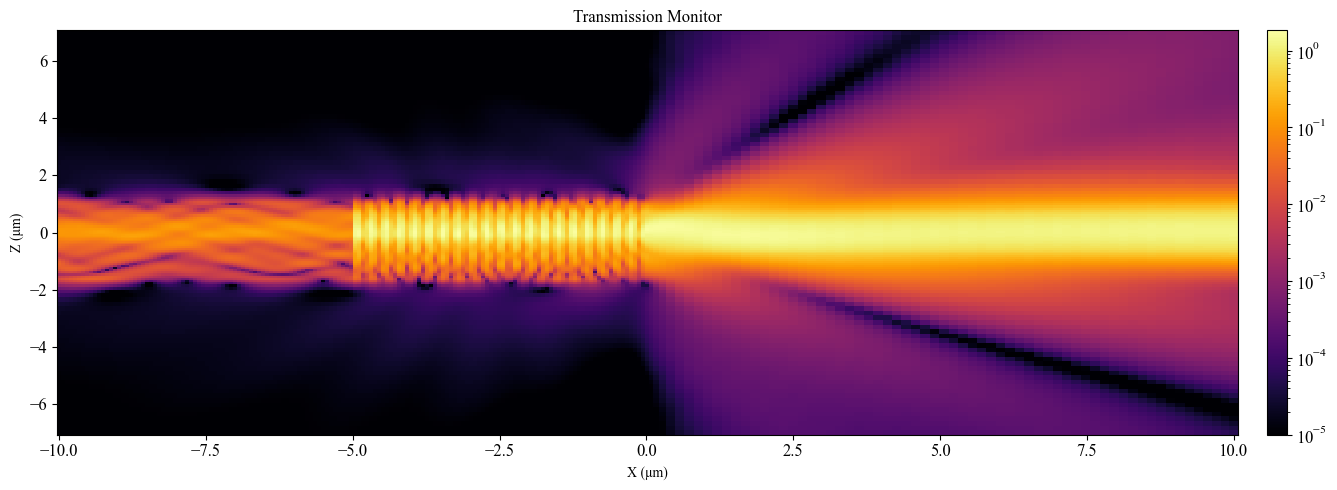

In [ ]:
transmission_E = fdtd.getresult("transmission_monitor", "E")
fig, ax = plt.subplots(figsize=(15, 5))
trans_E = transmission_E
E_field = trans_E['E']
Ex = E_field[:, 0, :, 0, 0]
Ey = E_field[:, 0, :, 0, 1]
Ez = E_field[:, 0, :, 0, 2]
E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
x_trans = np.squeeze(trans_E['x']) * 1e6  # (381,)
z_trans = np.squeeze(trans_E['z']) * 1e6  # (101,)
X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')

vmin = 1e-5
vmax = np.nanmax(E_intensity_trans)
data_to_plot = E_intensity_trans
norm = LogNorm(vmin=vmin, vmax=vmax)
pcm = ax.pcolormesh(X_trans, Z_trans, data_to_plot, cmap="inferno", shading='auto', norm=norm)
cbar = fig.colorbar(pcm, ax=ax, pad=0.02, format=ticker.LogFormatterSciNotation())
ax.set_xlabel('X (μm)')
ax.set_ylabel('Z (μm)')
ax.set_title('Transmission Monitor')

plt.tight_layout()
plt.show()

In [ ]:
print((trans_E['E']).shape)

In [ ]:
input_E = fdtd.getresult("input_monitor", "E")
fig, ax = plt.subplots(figsize=(6, 5))
E_field = input_E['E']
Ex = E_field[0, :, :, 0, 0]
Ey = E_field[0, :, :, 0, 1]
Ez = E_field[0, :, :, 0, 2]
E_intensity_input = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
y_input = np.squeeze(input_E['y']) * 1e6  # (381,)
z_input = np.squeeze(input_E['z']) * 1e6  # (101,)
Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')

vmin = 1e-3
vmax = np.nanmax(E_intensity_input)
data_to_plot = E_intensity_input

norm = LogNorm(vmin=vmin, vmax=vmax)
pcm = ax.pcolormesh(Y_input, Z_input, data_to_plot, cmap="inferno", shading='auto', norm=norm)

# 对数色条
# cbar = fig.colorbar(pcm, ax=ax, pad=0.02, format=ticker.LogFormatterSciNotation())

plt.tight_layout()
plt.show()

In [ ]:
middle_E = fdtd.getresult("middle_monitor", "E")
fig, ax = plt.subplots(figsize=(6, 5))
E_field = middle_E['E']
Ex = E_field[0, :, :, 0, 0]
Ey = E_field[0, :, :, 0, 1]
Ez = E_field[0, :, :, 0, 2]
E_intensity_middle = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
y_middle = np.squeeze(middle_E['y']) * 1e6  # (381,)
z_middle = np.squeeze(middle_E['z']) * 1e6  # (101,)
Y_middle, Z_middle = np.meshgrid(y_middle, z_middle, indexing='ij')

vmin = 1e-3
vmax = np.nanmax(E_intensity_middle)
data_to_plot = E_intensity_middle

norm = LogNorm(vmin=vmin, vmax=vmax)
pcm = ax.pcolormesh(Y_middle, Z_middle, data_to_plot, cmap="inferno", shading='auto', norm=norm)

# 对数色条
# cbar = fig.colorbar(pcm, ax=ax, pad=0.02, format=ticker.LogFormatterSciNotation())
plt.show()

In [ ]:
output_E = fdtd.getresult("output_monitor", "E")
fig, ax = plt.subplots(figsize=(6, 5))
E_field = output_E['E']
Ex = E_field[0, :, :, 0, 0]
Ey = E_field[0, :, :, 0, 1]
Ez = E_field[0, :, :, 0, 2]
E_intensity_output = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
y_output = np.squeeze(output_E['y']) * 1e6  # (381,)
z_output = np.squeeze(output_E['z']) * 1e6  # (101,)
Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')

vmin = 1e-3
vmax = np.nanmax(E_intensity_output)
data_to_plot = E_intensity_output

norm = LogNorm(vmin=vmin, vmax=vmax)
pcm = ax.pcolormesh(Y_output, Z_output, data_to_plot, cmap="inferno", shading='auto', norm=norm)
plt.show()

In [ ]:
output_E = fdtd.getresult("1", "E")
fig, ax = plt.subplots(figsize=(6, 5))
E_field = output_E['E']
Ex = E_field[0, :, :, 0, 0]
Ey = E_field[0, :, :, 0, 1]
Ez = E_field[0, :, :, 0, 2]
E_intensity_output = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
y_output = np.squeeze(output_E['y']) * 1e6  # (381,)
z_output = np.squeeze(output_E['z']) * 1e6  # (101,)
Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')

vmin = 1e-2
vmax = np.nanmax(E_intensity_output)
data_to_plot = E_intensity_output

norm = LogNorm(vmin=vmin, vmax=vmax)
pcm = ax.pcolormesh(Y_output, Z_output, data_to_plot, cmap="inferno", shading='auto', norm=norm)
plt.show()

In [2]:
fdtd = lumapi.FDTD()
fdtd.load("D:/simulation/Simulation Project/simulation/LD-PWB-SMF/LD -copy.fsp")

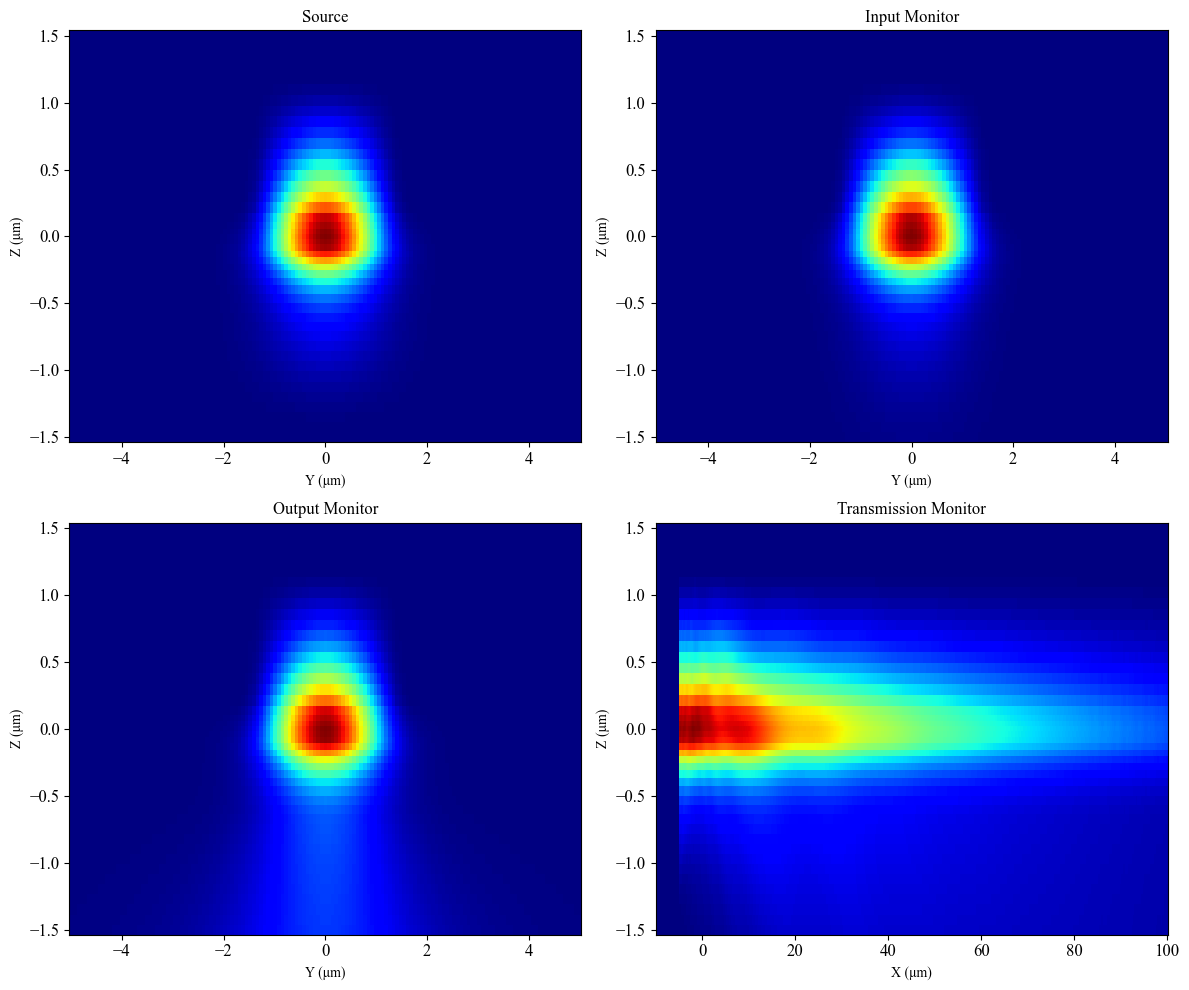

0.2435974974139665


In [10]:
source_E = fdtd.getresult("source", "mode profile")
transmission_E = fdtd.getresult("transmission", "E")
input_E = fdtd.getresult("input", "E")
output_E = fdtd.getresult("output", "E")
mode_data = fdtd.getresult("mem", "expansion for output")
T_forward = mode_data["T_forward"][0][0]

results = {
    'source_E': source_E,
    'transmission_E': transmission_E,
    'input_E': input_E,
    'output_E': output_E,
    'T_forward': T_forward
}

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
# 1. 绘制source、input_monitor、output_monitor和transmission_monitor的E场
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# source的E场 (2D X-normal)
source_E = results['source_E']
E_source = source_E['E']
Ex_source = E_source[0, :, :, 0, 0]
Ey_source = E_source[0, :, :, 0, 1]
Ez_source = E_source[0, :, :, 0, 2]
E_suorce_abs = np.abs(Ex_source)**2 + np.abs(Ey_source)**2 + np.abs(Ez_source)**2
y_source = np.squeeze(source_E['y']) * 1e6 #移除长度为1的维度
z_source = np.squeeze(source_E['z']) * 1e6
# 测试数组格式和大小
# print(source_E)
# print(E_source.shape, y_source.shape, z_source.shape)
# 创建网格
Y_source, Z_source = np.meshgrid(y_source, z_source, indexing='ij')
im1 = ax1.pcolormesh(Y_source, Z_source, E_suorce_abs, cmap="jet", shading='auto')
ax1.set_xlabel('Y (μm)')
ax1.set_ylabel('Z (μm)')
ax1.set_title('Source')
# plt.colorbar(im1, ax=ax1)

# input_monitor的E场 (2D X-normal)
input_E = results['input_E']
E_field_in = input_E['E']
Ex_in = E_field_in[0, :, :, 0, 0]
Ey_in = E_field_in[0, :, :, 0, 1]
Ez_in = E_field_in[0, :, :, 0, 2]
E_intensity_input = np.abs(Ex_in)**2 + np.abs(Ey_in)**2 + np.abs(Ez_in)**2
y_input = np.squeeze(input_E['y']) * 1e6
z_input = np.squeeze(input_E['z']) * 1e6
Y_input, Z_input = np.meshgrid(y_input, z_input, indexing='ij')
im2 = ax2.pcolormesh(Y_input, Z_input, E_intensity_input, cmap="jet", shading='auto')
ax2.set_xlabel('Y (μm)')
ax2.set_ylabel('Z (μm)')
ax2.set_title('Input Monitor')
# plt.colorbar(im2, ax=ax2)

# output_monitor的E场 (2D X-normal)
output_E = results['output_E']
E_field_out = output_E['E']
Ex_out = E_field_out[0, :, :, 0, 0]
Ey_out = E_field_out[0, :, :, 0, 1]
Ez_out = E_field_out[0, :, :, 0, 2]
E_intensity_output = np.abs(Ex_out)**2 + np.abs(Ey_out)**2 + np.abs(Ez_out)**2
y_output = np.squeeze(output_E['y']) * 1e6
z_output = np.squeeze(output_E['z']) * 1e6
Y_output, Z_output = np.meshgrid(y_output, z_output, indexing='ij')
im3 = ax3.pcolormesh(Y_output, Z_output, E_intensity_output, cmap="jet", shading='auto')
ax3.set_xlabel('Y (μm)')
ax3.set_ylabel('Z (μm)')
ax3.set_title('Output Monitor')
# plt.colorbar(im3, ax=ax3)

# transmission_monitor的E场 (2D Y-normal)
trans_E = results['transmission_E']
E_field = trans_E['E']
Ex = E_field[:, 0, :, 0, 0]
Ey = E_field[:, 0, :, 0, 1]
Ez = E_field[:, 0, :, 0, 2]
E_intensity_trans = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
x_trans = np.squeeze(trans_E['x']) * 1e6  # (381,)
z_trans = np.squeeze(trans_E['z']) * 1e6  # (101,)
X_trans, Z_trans = np.meshgrid(x_trans, z_trans, indexing='ij')

im4 = ax4.pcolormesh(X_trans, Z_trans, E_intensity_trans, cmap="jet", shading='auto')
ax4.set_xlabel('X (μm)')
ax4.set_ylabel('Z (μm)')
ax4.set_title('Transmission Monitor')
# plt.colorbar(im4, ax=ax4)

plt.tight_layout()
plt.show()
print(results['T_forward'])